# Análise Espectroscópica

Este notebook segue as melhores práticas da literatura para análise espectroscópica robusta, incluindo:
- Cross Validation
- Remoção de outliers espectrais (PCA, T²/Q)
- Remoção de outliers dos atributos (boxplot + seaborn)
- Teste de todos os filtros (dependentes e independentes de y)
- Modelagem com PLSR, PCR, RFR, SVMR (hiperparâmetros da literatura)
- Plotagens robustas e salvamento de métricas

## 1. Imports

In [27]:
# Imports necessários
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.mlab import detrend
import pywt
from sklearn.pipeline import Pipeline

# Cria diretórios para organizar todas as imagens salvas
print("Criando diretórios para salvar os gráficos...")
os.makedirs('graficos_outliers_pca', exist_ok=True)
os.makedirs('graficos_outliers_boxplot', exist_ok=True)
os.makedirs('modelos_salvos', exist_ok=True)
os.makedirs('graficos_modelos', exist_ok=True) 
os.makedirs('graficos_mlpr', exist_ok=True)

warnings.filterwarnings('ignore')

# Configurações de plot
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

Criando diretórios para salvar os gráficos...


## 2. Carregamento dos Dados

O primeiro passo em qualquer projeto de ciência de dados é carregar e entender os dados. Nesta seção, realizamos as seguintes ações:
- **Carregamento:** Utilizamos a biblioteca `pandas` para ler o arquivo `Avaliacao_Maturacao_Palmer_e_Tommy_Fieldspec.xlsx`, que contém os dados espectrais e os valores de referência (atributos físico-químicos).
- **Separação de Dados:** A função `load_data` inteligentemente separa o arquivo em duas partes:
    - `metadata`: Um DataFrame contendo as informações de referência (ex: Firmness, Dry Mass, TSS, TA, AA), que serão nossas variáveis-alvo (y).
    - `wavelengths`: Um DataFrame contendo a resposta espectral (absorbância ou reflectância) em cada comprimento de onda, que serão nossas variáveis preditoras (X).
- **Definição de Variáveis:** Convertemos os dados espectrais para um array NumPy (`X`) para otimizar os cálculos e definimos a lista de `atributos` que desejamos modelar.

In [28]:
# Função para carregar dados
def load_data(filepath):
    """Carrega dados espectrais e separa metadados de espectros."""
    df = pd.read_excel(filepath, engine='openpyxl')
    
    # Identificar colunas que são comprimentos de onda (numéricas)
    numeric_cols = []
    for col in df.columns:
        try:
            float(col)
            numeric_cols.append(col)
        except ValueError:
            continue
    
    # Separar metadados e comprimentos de onda
    metadata = df.drop(columns=numeric_cols)
    wavelengths = df[numeric_cols]
    
    return metadata, wavelengths

# Carregar dados
filepath = '../Data/filtros_u/teste_codigo_osc.xlsx'
metadata, wavelengths = load_data(filepath)
X = wavelengths.values
wavelength_values = wavelengths.columns.astype(float)

# VARIÁVEIS DA SARAH
atributos = ['Firmness (N)']

print(f'Dados carregados: {X.shape[0]} amostras, {X.shape[1]} comprimentos de onda')
print(f'Faixa espectral: {wavelength_values.min():.1f} - {wavelength_values.max():.1f} nm')
print(f'Atributos disponíveis: {list(metadata.columns)}')
print(f'Atributos a analisar: {atributos}')

# remoção de NaN antes de passar pelo pré-processamento e conferência

dados_completos = {}
for atributo in atributos:
    y = metadata[atributo].values
    original_indices = np.arange(len(y))
    
    # Remove apenas valores NaN
    mask = ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]
    original_indices_clean = original_indices[mask]
    
    dados_completos[atributo] = {
        'X': X_clean,
        'y': y_clean,
        'indices_orig': original_indices_clean
    }
    
    print(f'{atributo}: {X_clean.shape[0]} amostras válidas')

print(f'\nPreparação dos dados concluída para {len(atributos)} atributos!')


Dados carregados: 120 amostras, 2151 comprimentos de onda
Faixa espectral: 350.0 - 2500.0 nm
Atributos disponíveis: ['Samples', 'Stage', 'Variety', 'Firmness (N)', 'Dry Mass (%)', 'TSS (Brix)', 'TA (g/mL)', 'AA (mg/100g)', 'Weight (g)', 'Width (mm)', 'Length (mm)']
Atributos a analisar: ['Firmness (N)']
Firmness (N): 120 amostras válidas

Preparação dos dados concluída para 1 atributos!


## 4. Remoção de Outliers Espectrais (PCA, T²/Q)

Outliers espectrais são amostras cujo espectro é muito diferente do resto da população, podendo ser causados por erros de medição, contaminação ou características únicas da amostra. Eles podem prejudicar significativamente a capacidade de generalização do modelo.
- **Método PCA (T²/Q):** Usamos a Análise de Componentes Principais (PCA) para identificar esses outliers.
    - **Estatística T² (Hotelling's T²):** Mede a variação de uma amostra *dentro* do modelo PCA. Valores altos indicam que a amostra é um outlier na combinação das variáveis principais.
    - **Estatística Q (Resíduos):** Mede a variação da amostra *fora* do modelo PCA (o que o modelo não conseguiu capturar). Valores altos indicam que a estrutura do espectro da amostra é anormal.
- **Lógica:** Uma amostra é considerada outlier se seu valor de T² ou Q ultrapassa um limite de confiança (geralmente 3 desvios padrão da média).
- **Importante:** A remoção de outliers é feita **apenas no conjunto de calibração**. O conjunto de validação deve permanecer intacto para simular dados "reais" que o modelo encontrará no futuro.

In [29]:
def pca_outlier_removal(X, n_components=10, threshold=3):
    """Remove outliers usando PCA com estatísticas T² e Q."""
    # Padronizar dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Aplicar PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Calcular estatística T² (Hotelling's T²)
    T2 = np.sum((X_pca / np.std(X_pca, axis=0)) ** 2, axis=1)
    
    # Calcular estatística Q (resíduos)
    X_reconstructed = pca.inverse_transform(X_pca)
    Q = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)
    
    # Definir limites (média + threshold * desvio padrão)
    T2_limit = np.mean(T2) + threshold * np.std(T2)
    Q_limit = np.mean(Q) + threshold * np.std(Q)
    
    # Identificar outliers
    outliers_mask = (T2 > T2_limit) | (Q > Q_limit)
    
    # Retornamos a máscara de quem NÃO é outlier e o modelo PCA treinado
    return ~outliers_mask, pca, T2, Q, T2_limit, Q_limit

dados_pca = {}

#para todo o conjunto de dado e não separado em cal e val
for atributo in atributos:
    X_full = dados_completos[atributo]['X']
    y_full = dados_completos[atributo]['y']
    indices_orig_full = dados_completos[atributo]['indices_orig']
    
    # Chama a função de remoção de outliers espectrais
    keep_mask, pca_model, T2, Q, T2_limit, Q_limit = pca_outlier_removal(X_full)
    
    # Identifica e informa os outliers removidos
    outliers_indices = indices_orig_full[~keep_mask]
    print(f'{atributo}: {len(outliers_indices)} outliers espectrais removidos.')
    if len(outliers_indices) > 0:
        print(f'  Índices Originais Removidos: {outliers_indices}')
    
    # Filtra os dados
    X_clean = X_full[keep_mask]
    y_clean = y_full[keep_mask]
    indices_orig_clean = indices_orig_full[keep_mask]
    
    dados_pca[atributo] = {
        'X': X_clean,
        'y': y_clean,
        'indices_orig': indices_orig_clean,
        'pca_model': pca_model,
        'T2': T2,
        'Q': Q,
        'T2_limit': T2_limit,
        'Q_limit': Q_limit,
        'keep_mask': keep_mask
    }
    
    print(f'  Dataset final: {X_clean.shape[0]} amostras')
    print()


Firmness (N): 4 outliers espectrais removidos.
  Índices Originais Removidos: [ 50  74  97 113]
  Dataset final: 116 amostras



### 4.1 Gráficos de Outliers T² e Q

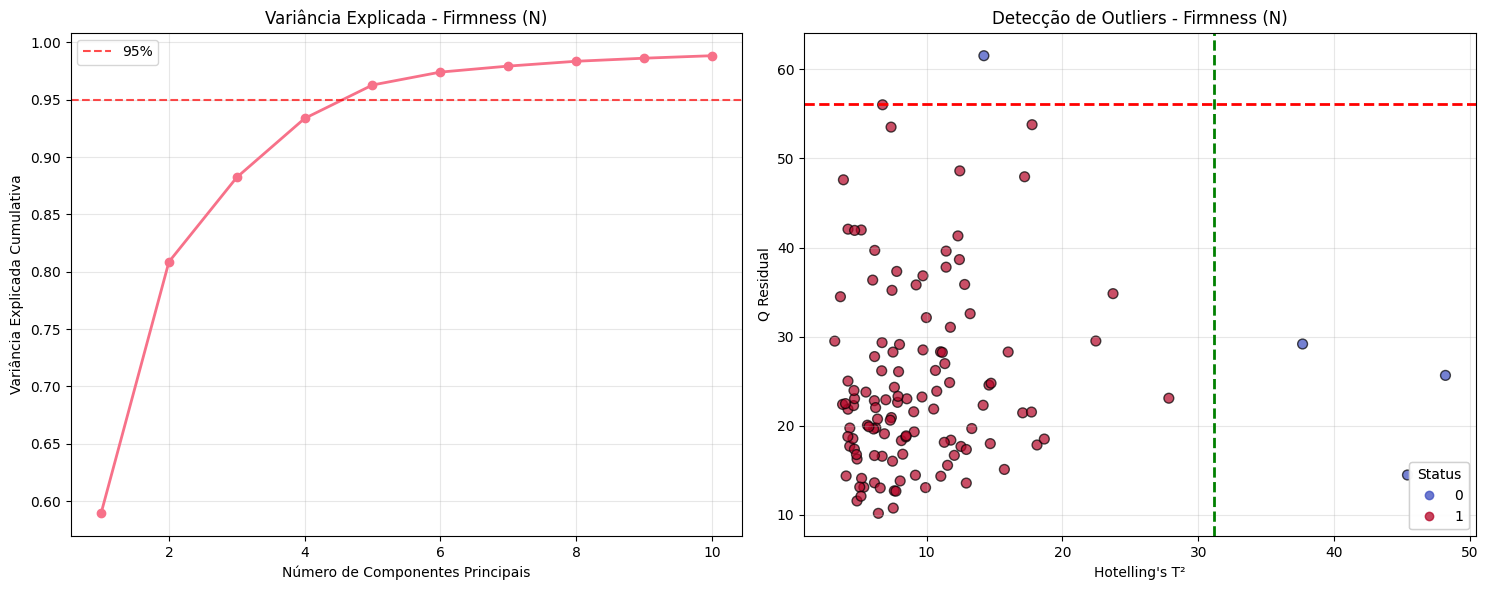

Gráficos de outliers PCA para Firmness (N) salvos em: graficos_outliers_pca/pca_outliers_Firmness_N.png



In [30]:
# Plotagem dos gráficos de outliers PCA
for atributo in atributos:
    d = dados_pca[atributo]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico 1: Variância explicada cumulativa
    # Acessa o modelo PCA com a chave correta 'pca_model'

    cumulative_variance = np.cumsum(d['pca_model'].explained_variance_ratio_)
    axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', linewidth=2, markersize=6)
    axes[0].set_xlabel('Número de Componentes Principais')
    axes[0].set_ylabel('Variância Explicada Cumulativa')
    axes[0].set_title(f'Variância Explicada - {atributo}')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95%')
    axes[0].legend()
    
    # Gráfico 2: T² vs Q (detecção de outliers)
    # Acessa as variáveis T2, Q, T2_limit, Q_limit e keep_mask com as chaves corretas
    scatter = axes[1].scatter(d['T2'], d['Q'], c=d['keep_mask'], cmap='coolwarm', 
                              edgecolor='k', alpha=0.7, s=50)
    axes[1].axhline(d['Q_limit'], color='r', linestyle='--', linewidth=2, label=f'Q Limit: {d["Q_limit"]:.2f}')
    axes[1].axvline(d['T2_limit'], color='g', linestyle='--', linewidth=2, label=f'T² Limit: {d["T2_limit"]:.2f}')
    axes[1].set_xlabel("Hotelling's T²")
    axes[1].set_ylabel('Q Residual')
    axes[1].set_title(f'Detecção de Outliers - {atributo}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Adicionar legenda de cores
    legend1 = axes[1].legend(*scatter.legend_elements(), title="Status")
    axes[1].add_artist(legend1)
    
    plt.tight_layout()
    
    # Salvar gráfico
    nome_arquivo = f'graficos_outliers_pca/pca_outliers_{atributo.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")}.png'
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f'Gráficos de outliers PCA para {atributo} salvos em: {nome_arquivo}')
    print()

## 5. Remoção de Outliers dos Atributos (Boxplot + Seaborn)

Além dos outliers espectrais (em X), podemos ter outliers nos valores de referência (em y). Por exemplo, um valor de pH ou SST que é analiticamente improvável ou resultado de um erro de anotação.
- **Método (IQR):** O método do Intervalo Interquartil (IQR) é uma forma estatística robusta de identificar esses pontos.
    - `IQR = Q3 (percentil 75) - Q1 (percentil 25)`
    - Um valor é considerado outlier se estiver abaixo de `Q1 - 1.5 * IQR` ou acima de `Q3 + 1.5 * IQR`.
- **Visualização:** O `boxplot` é a ferramenta visual perfeita para essa análise, pois ele desenha os "bigodes" exatamente nesses limites de 1.5 * IQR, mostrando os outliers como pontos individuais.
- **Ação:** Novamente, a remoção é feita apenas no conjunto de calibração.

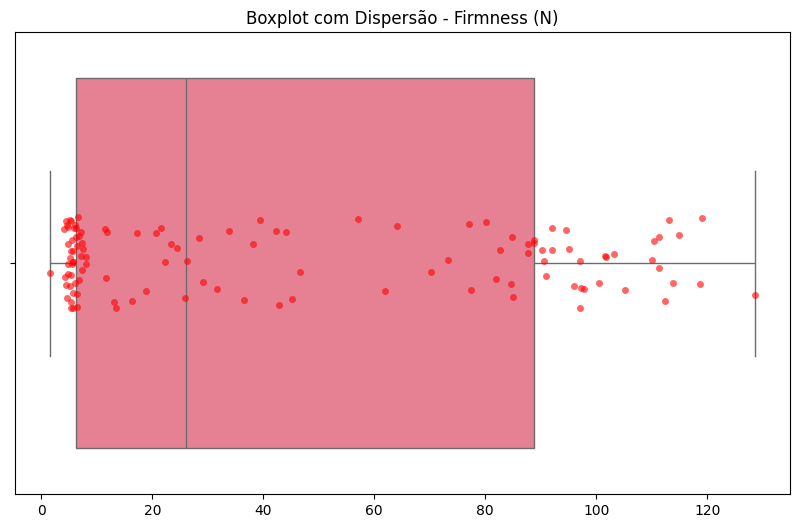

Firmness (N): 0 outliers de atributo removidos.
  Dataset final para modelagem: 116 amostras

Remoção de outliers concluída!


In [31]:
# Remover outliers dos atributos usando boxplot e IQR

dados_final = {}

for atributo in atributos:
    # Pega os dados já limpos de outliers espectrais
    d = dados_pca[atributo]
    X_clean = d['X']
    y_clean = d['y']
    indices_orig_clean = d['indices_orig']
    
    # Boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=y_clean)
    sns.stripplot(x=y_clean, color='red', alpha=0.6)
    plt.title(f'Boxplot com Dispersão - {atributo}')
    
    nome_arquivo = f'graficos_outliers_boxplot/boxplot_outliers_{atributo.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")}.png'
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    plt.show()

    # Lógica de remoção de outliers dos atributos
    Q1 = np.percentile(y_clean, 25)
    Q3 = np.percentile(y_clean, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    keep_mask_attr = (y_clean >= lower_bound) & (y_clean <= upper_bound)
    
    # Identifica e informa os outliers removidos
    outliers_attr_indices = indices_orig_clean[~keep_mask_attr]
    print(f'{atributo}: {len(outliers_attr_indices)} outliers de atributo removidos.')
    if len(outliers_attr_indices) > 0:
        print(f'  Índices Originais Removidos: {outliers_attr_indices}')
    
    # Armazena os dados finais e limpos para modelagem
    dados_final[atributo] = {
        'X': X_clean[keep_mask_attr],
        'y': y_clean[keep_mask_attr]
    }
    
    print(f'  Dataset final para modelagem: {dados_final[atributo]["X"].shape[0]} amostras')
    print()

print("Remoção de outliers concluída!")

In [32]:
# --- Função para o Gráfico de CALIBRAÇÃO (Ref vs Predito vs CV) ---
def save_calibration_plot(y_cal, y_pred_cal, y_pred_cv, atributo, modelo, file_path):
    """
    Gera e salva um gráfico comparando predições de treino e de validação cruzada
    no conjunto de calibração.
    """
    try:
        # Garante que o diretório exista
        os.makedirs(os.path.dirname(file_path), exist_ok=True)

        # Métricas para Predição no Treino Completo
        slope_pred, offset_pred = np.polyfit(y_cal, y_pred_cal, 1)
        rmse_pred = np.sqrt(mean_squared_error(y_cal, y_pred_cal))
        r2_pred = r2_score(y_cal, y_pred_cal)

        # Métricas para Predição da Validação Cruzada
        slope_cv, offset_cv = np.polyfit(y_cal, y_pred_cv, 1)
        rmse_cv = np.sqrt(mean_squared_error(y_cal, y_pred_cv))
        r2_cv = r2_score(y_cal, y_pred_cv)

        plt.figure(figsize=(10, 8))
        plt.scatter(y_cal, y_pred_cal, color='blue', marker='o', alpha=0.6, label=f'Predição no Treino (R²={r2_pred:.3f})')
        plt.scatter(y_cal, y_pred_cv, color='red', marker='x', alpha=0.7, label=f'Predição CV (R²={r2_cv:.3f})')
        
        # Linha ideal 1:1
        min_val = min(min(y_cal), min(y_pred_cal), min(y_pred_cv))
        max_val = max(max(y_cal), max(y_pred_cal), max(y_pred_cv))
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Linha Ideal (1:1)')

        plt.xlabel("Valores Reais (Calibração)")
        plt.ylabel("Valores Preditos")
        plt.title(f'Desempenho na Calibração: {atributo} | {modelo} | {filtro}')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='lower right')
        
        # Adiciona texto com métricas
        stats_text = (
            f'Treino - RMSE: {rmse_pred:.3f}, Slope: {slope_pred:.3f}, Offset: {offset_pred:.3f}\n'
            f'CV     - RMSE: {rmse_cv:.3f}, Slope: {slope_cv:.3f}, Offset: {offset_cv:.3f}'
        )
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

        plt.savefig(file_path, format='png', dpi=200, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Erro ao gerar gráfico de calibração para {modelo} com {filtro}: {e}")
        plt.close()


# --- Função para o Gráfico de VALIDAÇÃO (Predito vs Real) ---
def save_validation_plot(y_val, y_pred_val, atributo, filtro, modelo, file_path):
    """
    Gera e salva o gráfico de predições no conjunto de validação (teste).
    """
    try:
        # Garante que o diretório exista
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        
        # Métricas
        r2 = r2_score(y_val, y_pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        slope, offset = np.polyfit(y_val, y_pred_val, 1)

        plt.figure(figsize=(8, 8))
        plt.scatter(y_val, y_pred_val, alpha=0.7, edgecolors='k', label='Dados de Validação')
        
        # Linha ideal 1:1
        min_val = min(min(y_val), min(y_pred_val))
        max_val = max(max(y_val), max(y_pred_val))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Linha Ideal (1:1)')

        plt.xlabel('Valores Reais (Validação)')
        plt.ylabel('Valores Preditos')
        plt.title(f'Desempenho na Validação: {atributo} | {modelo} | {filtro}')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        stats_text = f'R² = {r2:.4f}\nRMSE = {rmse:.4f}\nSlope = {slope:.4f}'
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.5))
        
        plt.legend()
        plt.savefig(file_path, format='png', dpi=200, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Erro ao gerar gráfico de validação para {modelo} com {filtro}: {e}")
        plt.close()


## 6. Avaliação dos Filtros e Seleção dos Melhores Modelos com Validação Cruzada

Nesta etapa crucial, construímos e avaliamos os modelos de regressão. Em vez de testar cada modelo separadamente, criamos um fluxo automatizado e exaustivo para garantir que encontremos a melhor performance possível.
- **Estratégia:**
    1. **Iteração por Atributo:** Um loop externo passa por cada variável alvo (AT, PH, etc.).
    2. **Iteração por Modelo:** Para cada atributo, testamos uma lista de modelos quimiométricos:
        - `PLSR`: Padrão da área, lida bem com multicolinearidade.
        - `PCR`: Alternativa que primeiro reduz a dimensionalidade.
        - `RFR` (Random Forest): Modelo não-linear, robusto e poderoso.
        - `SVMR` (Support Vector Machine): Eficaz em espaços de alta dimensão.
    3. **Iteração por Filtro:** Para cada modelo, aplicamos **todos os 16 filtros** de pré-processamento definidos na seção anterior.
    4. **Otimização (GridSearchCV):** Para cada combinação `(atributo, modelo, filtro)`, usamos `GridSearchCV` com validação cruzada (10-fold) para encontrar os melhores hiperparâmetros do modelo (ex: número de componentes para PLS, parâmetros C e gamma para SVM).
- **Avaliação:** O desempenho de cada combinação é medido pelo R² da validação cruzada. O melhor modelo é então treinado com todos os dados de calibração e sua performance final é avaliada no conjunto de validação, que foi mantido separado durante todo o processo.
- **Saídas:** Ao final, teremos os resultados de centenas de modelos, permitindo uma comparação justa e a seleção do campeão para cada atributo. Todos os gráficos de predição e as métricas são salvos automaticamente.

In [33]:
def save_calibration_plot_cv(y_true, y_pred_cv, atributo, filtro, modelo, file_path):
    """Salva gráfico de cross-validation"""
    try:
        os.makedirs(os.path.dirname(file_path), exist_ok=True)

        slope_cv, offset_cv = np.polyfit(y_true, y_pred_cv, 1)
        rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred_cv))
        r2_cv = r2_score(y_true, y_pred_cv)

        plt.figure(figsize=(10, 8))
        plt.scatter(y_true, y_pred_cv, color='blue', marker='o', alpha=0.7, label=f'Cross-Validation (R²={r2_cv:.3f})')
        
        min_val = min(min(y_true), min(y_pred_cv))
        max_val = max(max(y_true), max(y_pred_cv))
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Linha Ideal (1:1)')

        plt.xlabel("Valores Reais")
        plt.ylabel("Valores Preditos (CV)")
        plt.title(f'Cross-Validation: {atributo} | {modelo} | {filtro}')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='lower right')
        
        stats_text = f'CV - R²: {r2_cv:.3f}, RMSE: {rmse_cv:.3f}, Slope: {slope_cv:.3f}, Offset: {offset_cv:.3f}'
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

        plt.savefig(file_path, format='png', dpi=200, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Erro ao gerar gráfico de CV para {modelo} com {filtro}: {e}")
        plt.close()


### 6.1 Modelos e Grids de Parâmetros

In [34]:
import re
import time
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Imports que você precisa garantir que existam no seu ambiente ---
# Certifique-se de que estas classes estejam importadas corretamente
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
# --------------------------------------------------------------------


class SpectroscopyModelValidator:
    def __init__(self, cv_folds=10, random_state=42, n_jobs=-1):
        """
        Inicializa o validador.
        """
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    def get_models_config(self):
        """
        Definição dos modelos e dos grids de hiperparâmetros.
        """
        return {
            'PLSR': {
                'estimador': PLSRegression(),
                'params': {'n_components': [15]}
            },
            'PCR': {
                'estimador': Pipeline([('pca', PCA()), ('regressor', LinearRegression())]),
                'params': {'pca__n_components': [5, 10, 15, 20]}
            },
            'SVMR': {
                'estimador': SVR(),
                'params': {
                    'C': [0.1, 1, 10, 100],
                    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                    'kernel': ['rbf', 'linear'],
                    'epsilon': [0.1, 0.2, 0.5, 1.0]
                }
            }
       }

    def run_validation(self, atributos, dados_final, target_attributes=None):
    
        if target_attributes is None:
            # Se não for especificado, usa as chaves de 'dados_final' como atributos
            target_attributes = list(dados_final.keys())

        modelos = self.get_models_config()
        lista_resultados_finais = []

        # Criar diretórios necessários
        os.makedirs('graficos_modelos/cross_validation', exist_ok=True)
        os.makedirs('modelos_salvos', exist_ok=True)

        for atributo in target_attributes:
            print(f'\n{"="*50}')
            print(f'PROCESSANDO ATRIBUTO: {atributo}')
            print(f'{"="*50}')

            melhor_r2_atributo = -float('inf')
            melhor_combinacao_info = {}
            
            # Garante que o atributo existe no dicionário
            if atributo not in dados_final:
                print(f"AVISO: Atributo '{atributo}' não encontrado em 'dados_final'. Pulando.")
                continue

            dados = dados_final[atributo]
            X_full, y_full = dados['X'], dados['y']

            for nome_modelo, info_modelo in modelos.items():
                # ALTERAÇÃO: Removido o loop de filtros. Agora chamamos um método
                # que avalia apenas o modelo.
                resultado = self._evaluate_model(
                    nome_modelo, info_modelo,
                    X_full, y_full,
                    atributo
                )

                if resultado:
                    lista_resultados_finais.append(resultado)

                    # Atualizar melhor combinação geral para o atributo
                    if resultado['CV_R2_Mean'] > melhor_r2_atributo:
                        melhor_r2_atributo = resultado['CV_R2_Mean']
                        melhor_combinacao_info = {
                            'objeto_modelo': resultado['objeto_modelo'],
                            'nome_modelo': nome_modelo,
                            'parametros': resultado['Melhores_Params']
                        }

            # Salvar melhor modelo geral
            self._save_best_model(melhor_combinacao_info, atributo, melhor_r2_atributo)
            

        # Salvar resultados completos
        return self._save_complete_results(lista_resultados_finais)

    def _evaluate_model(self, nome_modelo, info_modelo, X_full, y_full, atributo):
        """
        Testa um modelo específico usando GridSearchCV.
        Este método substitui o '_test_filter_model_combination'.
        """
        start_time = time.time()
        print(f'  Testando Modelo: {nome_modelo}...', end='')

        try:
            # O estimador é usado diretamente, sem o FilterTransformer
            estimador = info_modelo['estimador']
            params = info_modelo['params']

            # Grid search
            grid = GridSearchCV(
                estimador,
                params,
                cv=self.kf,
                scoring='r2',
                n_jobs=self.n_jobs
            )

            grid.fit(X_full, y_full)
            melhor_modelo = grid.best_estimator_

            # Métricas
            cv_r2_mean = grid.best_score_
            best_index = grid.best_index_
            cv_r2_std = grid.cv_results_['std_test_score'][best_index] if 'std_test_score' in grid.cv_results_ else np.nan
            
            y_pred_cv = cross_val_predict(melhor_modelo, X_full, y_full, cv=self.kf, n_jobs=self.n_jobs)
            cv_rmse = np.sqrt(mean_squared_error(y_full, y_pred_cv))

            end_time = time.time()
            print(f' CV R²: {cv_r2_mean:.4f} (±{cv_r2_std:.4f}) | Concluído em {end_time - start_time:.2f}s')
            
            # Salvar gráfico de calibração
            self._save_calibration_plot(y_full, y_pred_cv, atributo, nome_modelo)

            return {
                'Atributo': atributo,
                'Modelo': nome_modelo,
                'CV_R2_Mean': cv_r2_mean,
                'CV_R2_Std': cv_r2_std,
                'CV_RMSE': cv_rmse,
                'Melhores_Params': str(grid.best_params_),
                'Tempo_s': end_time - start_time,
                'objeto_modelo': melhor_modelo
            }

        except Exception as e:
            print(f' ERRO FATAL NO GRIDSEARCH para o modelo {nome_modelo}: {str(e)}')
            return None

    def _save_calibration_plot(self, y_true, y_pred, atributo, modelo):
        """Salva gráfico de calibração (sem alterações)."""
        try:
            plt.figure(figsize=(8, 6))
            plt.scatter(y_true, y_pred, alpha=0.6)
            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
            plt.xlabel('Valores Reais')
            plt.ylabel('Valores Preditos')
            plt.title(f'Calibração: {atributo} - {modelo}')

            r2 = r2_score(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            plt.text(0.05, 0.95, f'$R^2_{{cv}}$ = {r2:.4f}\n$RMSE_{{cv}}$ = {rmse:.4f}',
                     transform=plt.gca().transAxes, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            atributo_limpo = re.sub(r"[ \/\[\]\(\)]", "_", atributo)
            path_cv = f'graficos_modelos/cross_validation/{atributo_limpo}_{modelo}.png'
            plt.savefig(path_cv, dpi=300, bbox_inches='tight')
            plt.close()
        except Exception as e:
            print(f"Erro ao salvar gráfico: {e}")

    def _save_best_model(self, melhor_combinacao_info, atributo, melhor_r2):
        """Salva o melhor modelo (pequena alteração no print)."""
        atributo_limpo = re.sub(r"[ \/\[\]\(\)]", "_", atributo)
        if melhor_combinacao_info and melhor_combinacao_info.get('objeto_modelo') is not None:
            nome_arquivo = f"modelos_salvos/melhor_modelo_{atributo_limpo}.joblib"
            joblib.dump(melhor_combinacao_info['objeto_modelo'], nome_arquivo)

            print(f"\n🏆 MELHOR MODELO PARA '{atributo}' SALVO!")
            print(f"   Arquivo: {nome_arquivo}")
            # ALTERAÇÃO: Removido o print do filtro
            print(f"   Modelo: {melhor_combinacao_info['nome_modelo']}")
            print(f"   R² CV: {melhor_r2:.4f}")
        else:
             print(f"\nAVISO: Nenhum modelo válido foi treinado com sucesso para '{atributo}'. Nenhum objeto salvo.")


    def _save_complete_results(self, lista_resultados_finais):
        """Salva resultados completos em Excel (pequena alteração na exibição)."""
        if not lista_resultados_finais:
            print("\nNenhum resultado foi gerado. A análise foi concluída sem sucesso.")
            return None, None
            
        print('\n✅ Validação concluída!')

        df_completo = pd.DataFrame(lista_resultados_finais)
        df_completo_ordenado = df_completo.sort_values(
            by=['Atributo', 'CV_R2_Mean'],
            ascending=[True, False]
        )

        df_para_excel = df_completo_ordenado.drop('objeto_modelo', axis=1)
        df_para_excel.to_excel('analise_completa_resultados_cv.xlsx', index=False)
        print('✅ Resultados salvos em "analise_completa_resultados_cv.xlsx"')

        print("\n--- MELHORES RESULTADOS POR ATRIBUTO ---")
        melhores_resultados = df_completo_ordenado.groupby('Atributo').first().reset_index()

        colunas_numericas = ['CV_R2_Mean', 'CV_R2_Std', 'CV_RMSE']
        melhores_resultados[colunas_numericas] = melhores_resultados[colunas_numericas].round(4)
        
        # CORREÇÃO: Removida a vírgula extra e a coluna de filtro que não existe mais.
        colunas_exibir = ['Atributo', 'Modelo', 'CV_R2_Mean', 'CV_R2_Std', 'CV_RMSE', 'Melhores_Params']
        print(melhores_resultados[colunas_exibir].to_string(index=False))

        return df_completo_ordenado, melhores_resultados


# Função wrapper para iniciar a validação
def run_model_validation(atributos, dados_final):
    """
    Função wrapper simplificada para iniciar o processo.
    """
    validator = SpectroscopyModelValidator(cv_folds=10, random_state=42)
    # A chamada agora é mais simples
    return validator.run_validation(
        atributos=atributos, 
        dados_final=dados_final
    )





# # Se você quiser processar todos os atributos em 'dados_final':
resultados, melhores = run_model_validation(
     atributos=None, # Passando None fará com que a função use todas as chaves
     dados_final=dados_final
 )


PROCESSANDO ATRIBUTO: Firmness (N)
  Testando Modelo: PLSR... CV R²: 0.7873 (±0.1577) | Concluído em 0.55s
  Testando Modelo: PCR... CV R²: 0.6953 (±0.1438) | Concluído em 0.49s
  Testando Modelo: SVMR... CV R²: 0.7235 (±0.1522) | Concluído em 6.49s

🏆 MELHOR MODELO PARA 'Firmness (N)' SALVO!
   Arquivo: modelos_salvos/melhor_modelo_Firmness__N_.joblib
   Modelo: PLSR
   R² CV: 0.7873

✅ Validação concluída!
✅ Resultados salvos em "analise_completa_resultados_cv.xlsx"

--- MELHORES RESULTADOS POR ATRIBUTO ---
    Atributo Modelo  CV_R2_Mean  CV_R2_Std  CV_RMSE      Melhores_Params
Firmness (N)   PLSR      0.7873     0.1577  17.2706 {'n_components': 15}
